In [124]:
# ============================================================
# TCGA glioma telomere length and arm-level CNV analysis
# ============================================================

In [118]:
# -------------------------------
# Load required libraries
# -------------------------------
library(dplyr)
library(tidyr)
library(readr)
library(ggplot2)
library(ggpubr)
library(ggforce)
library(forcats)

In [119]:
# ============================================================
# 1. Load telomere and CNV segment data
# ============================================================

# Telomere length estimates from WGS
wgs <- read.table(
  "/tgen_labs/barthel/public_datasets/TCGA/telomere_length/WGS-Paired_set.txt",
  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
)
head(wgs)

,SampleID,Disease,Center,LibraryType,PatientID,PairType,nTL,tTL,TLratio,isCore,⋯,TERTfus,ATRXfus,TERTexprStatus,TERCstatus,ATRXstatus,DAXXstatus,ATRXDAXXstatus,TERTstatus,TERTalt,TERTexpr.ATRX.DAXXaltgrp
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<lgl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,FALSE,⋯,TERT intact,ATRX intact,TERT expr,TERC wt,ATRX mut,DAXX wt,ATRX/DAXX alt,,,TERT expr
2,TCGA-02-2485-01,GBM,BI,WGS,TCGA-02-2485,TP-NB,6.04,14.63,0.88,FALSE,⋯,TERT intact,ATRX intact,TERT expr,TERC wt,ATRX wt,DAXX wt,ATRX/DAXX wt,,,TERT expr
3,TCGA-04-1331-01,OV,BCM,WGS,TCGA-04-1331,TP-NB,5.39,19.72,1.30,FALSE,⋯,TERT intact,ATRX intact,,,,,,,,
4,TCGA-04-1367-01,OV,BCM,WGS,TCGA-04-1367,TP-NB,7.36,2.09,-1.26,FALSE,⋯,,,,,,,,,,
5,TCGA-04-1514-01,OV,BCM,WGS,TCGA-04-1514,TP-NB,6.47,3.08,-0.74,FALSE,⋯,TERT intact,ATRX intact,TERT expr,TERC wt,ATRX wt,DAXX wt,ATRX/DAXX wt,,,TERT expr
6,TCGA-04-1542-01,OV,BI,WGS,TCGA-04-1542,TP-NB,4.11,4.54,0.10,FALSE,⋯,TERT intact,ATRX intact,,,,,,,,


In [120]:
# CNV segment data
sample_scores <- read.table(
  "/tgen_labs/barthel/public_datasets/TCGA/cnv/PCTL.snp6.segmented_scna_minus_germline.hg19.seg.txt",
  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
)

In [121]:
# ============================================================
# 2. Standardize patient IDs and merge datasets
# ============================================================

# Extract TCGA patient-level IDs for matching
sample_scores$patient_id <- sub(
  "^(TCGA-[A-Z0-9]{2}-[0-9]{4}).*",
  "\\1",
  sample_scores$Sample
)

wgs$patient_id <- sub(
  "^(TCGA-[A-Z0-9]{2}-[0-9]{4}).*",
  "\\1",
  wgs$SampleID
)

In [123]:
# Merge telomere and CNV data
merged_all <- merge(wgs, sample_scores, by = "patient_id", all.x = TRUE)

# Restrict to glioma samples
merged_sub <- merged_all %>%
  filter(Disease %in% c("GBM", "LGG"))

# Quick checks
head(sample_scores)
unique(merged_sub$Disease)
colnames(merged_sub)

,Sample,Chromosome,Start,End,Num_Probes,Segment_Mean,patient_id
,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>
1,TCGA-RZ-AB0B-10A-01D-A39Y-01,1,3218610,105104370,58531,0.0017,TCGA-RZ-AB0B-10A-01D-A39Y-01
2,TCGA-RZ-AB0B-10A-01D-A39Y-01,1,105105350,105164486,29,-1.0825,TCGA-RZ-AB0B-10A-01D-A39Y-01
3,TCGA-RZ-AB0B-10A-01D-A39Y-01,1,105173095,247813706,70525,-0.0019,TCGA-RZ-AB0B-10A-01D-A39Y-01
4,TCGA-RZ-AB0B-10A-01D-A39Y-01,2,484222,37464085,22113,0.0019,TCGA-RZ-AB0B-10A-01D-A39Y-01
5,TCGA-RZ-AB0B-10A-01D-A39Y-01,2,37464511,37464743,2,-1.4060,TCGA-RZ-AB0B-10A-01D-A39Y-01
6,TCGA-RZ-AB0B-10A-01D-A39Y-01,2,37468065,74146977,20863,0.0050,TCGA-RZ-AB0B-10A-01D-A39Y-01


[1] "GBM" "LGG"

[1] "patient_id"               "SampleID"                
 [3] "Disease"                  "Center"                  
 [5] "LibraryType"              "PatientID"               
 [7] "PairType"                 "nTL"                     
 [9] "tTL"                      "TLratio"                 
[11] "isCore"                   "isExtended"              
[13] "Age"                      "Gender"                  
[15] "OS"                       "S"                       
[17] "TERCexpr"                 "TERTexpr"                
[19] "ATRXexpr"                 "TERRAexpr"               
[21] "TERTamp"                  "TERCamp"                 
[23] "ATRXdel"                  "TP53del"                 
[25] "TP53mut"                  "ATRXmut"                 
[27] "TERTsv"                   "TERTpsv"                 
[29] "ATRXsv"                   "TERTpmut"                
[31] "TERTpmutsite"             "TERTpMethylationStatus"  
[33] "TelomeraseSignatureScore" "TERTfus"                 
[35] "ATRXfus"                  "TERTexprStatus"          
[37] "TERCstatus"               "ATRXstatus"              
[39] "DAXXstatus"               "ATRXDAXXstatus"          
[41] "TERTstatus"               "TERTalt"                 
[43] "TERTexpr.ATRX.DAXXaltgrp" "Sample"                  
[45] "Chromosome"               "Start"                   
[47] "End"                      "Num_Probes"              
[49] "Segment_Mean"

In [116]:
# ============================================================
# 3. Load subtype annotation and map subtype labels
# ============================================================

IDs <- read.table(
  "/home/mjehangir/telomere-sv-analysis/notebooks/tcga_analysis/glioma_status.txt",
  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
)

head(IDs)
head(merged_sub)
nrow(merged_sub)
colnames(merged_sub)

,WT,Non.codel,codel
,<chr>,<chr>,<chr>
1,TCGA-CS-4941,TCGA-CS-4938,TCGA-CS-5390
2,TCGA-CS-5395,TCGA-CS-4942,TCGA-CS-5396
3,TCGA-CS-5397,TCGA-CS-4943,TCGA-CS-6668
4,TCGA-CS-6186,TCGA-CS-4944,TCGA-CS-6670
5,TCGA-CS-6188,TCGA-CS-5393,TCGA-DB-5274
6,TCGA-CS-6669,TCGA-CS-5394,TCGA-DB-5278


,patient_id,SampleID,Disease,Center,LibraryType,PatientID,PairType,nTL,tTL,TLratio,⋯,TERTstatus,TERTalt,TERTexpr.ATRX.DAXXaltgrp,Sample,Chromosome,Start,End,Num_Probes,Segment_Mean,subtype
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>
1,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,132293507,132294278,6,0.0262,Non.codel
2,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,1,3218610,5101936,1257,-0.1771,Non.codel
3,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,135792178,136560244,449,0.9149,Non.codel
4,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,90468388,90469000,2,-1.1426,Non.codel
5,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-10A-01D-0784-01,16,653459,89379936,40797,0.0003,Non.codel
6,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-10A-01D-0784-01,22,17423930,49331012,16927,-0.0007,Non.codel


[1] 17798

[1] "patient_id"               "SampleID"                
 [3] "Disease"                  "Center"                  
 [5] "LibraryType"              "PatientID"               
 [7] "PairType"                 "nTL"                     
 [9] "tTL"                      "TLratio"                 
[11] "isCore"                   "isExtended"              
[13] "Age"                      "Gender"                  
[15] "OS"                       "S"                       
[17] "TERCexpr"                 "TERTexpr"                
[19] "ATRXexpr"                 "TERRAexpr"               
[21] "TERTamp"                  "TERCamp"                 
[23] "ATRXdel"                  "TP53del"                 
[25] "TP53mut"                  "ATRXmut"                 
[27] "TERTsv"                   "TERTpsv"                 
[29] "ATRXsv"                   "TERTpmut"                
[31] "TERTpmutsite"             "TERTpMethylationStatus"  
[33] "TelomeraseSignatureScore" "TERTfus"                 
[35] "ATRXfus"                  "TERTexprStatus"          
[37] "TERCstatus"               "ATRXstatus"              
[39] "DAXXstatus"               "ATRXDAXXstatus"          
[41] "TERTstatus"               "TERTalt"                 
[43] "TERTexpr.ATRX.DAXXaltgrp" "Sample"                  
[45] "Chromosome"               "Start"                   
[47] "End"                      "Num_Probes"              
[49] "Segment_Mean"             "subtype"

In [45]:
# Convert subtype annotation from wide to long format
# Expected columns in IDs: WT, Non.codel, codel
IDs_long <- IDs %>%
  pivot_longer(
    cols = everything(),
    names_to = "subtype",
    values_to = "patient_id"
  )

# Add subtype to merged dataset
merged_sub <- merged_sub %>%
  left_join(IDs_long, by = "patient_id")

head(merged_sub)
colnames(merged_sub)

,patient_id,SampleID,Disease,Center,LibraryType,PatientID,PairType,nTL,tTL,TLratio,⋯,TERTstatus,TERTalt,TERTexpr.ATRX.DAXXaltgrp,Sample,Chromosome,Start,End,Num_Probes,Segment_Mean,subtype
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>
1,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,132293507,132294278,6,0.0262,Non.codel
2,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,1,3218610,5101936,1257,-0.1771,Non.codel
3,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,135792178,136560244,449,0.9149,Non.codel
4,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-01A-01D-0784-01,9,90468388,90469000,2,-1.1426,Non.codel
5,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-10A-01D-0784-01,16,653459,89379936,40797,0.0003,Non.codel
6,TCGA-02-2483,TCGA-02-2483-01,GBM,BI,WGS,TCGA-02-2483,TP-NB,6.07,5.08,-0.18,⋯,,,TERT expr,TCGA-02-2483-10A-01D-0784-01,22,17423930,49331012,16927,-0.0007,Non.codel


[1] "patient_id"               "SampleID"                
 [3] "Disease"                  "Center"                  
 [5] "LibraryType"              "PatientID"               
 [7] "PairType"                 "nTL"                     
 [9] "tTL"                      "TLratio"                 
[11] "isCore"                   "isExtended"              
[13] "Age"                      "Gender"                  
[15] "OS"                       "S"                       
[17] "TERCexpr"                 "TERTexpr"                
[19] "ATRXexpr"                 "TERRAexpr"               
[21] "TERTamp"                  "TERCamp"                 
[23] "ATRXdel"                  "TP53del"                 
[25] "TP53mut"                  "ATRXmut"                 
[27] "TERTsv"                   "TERTpsv"                 
[29] "ATRXsv"                   "TERTpmut"                
[31] "TERTpmutsite"             "TERTpMethylationStatus"  
[33] "TelomeraseSignatureScore" "TERTfus"                 
[35] "ATRXfus"                  "TERTexprStatus"          
[37] "TERCstatus"               "ATRXstatus"              
[39] "DAXXstatus"               "ATRXDAXXstatus"          
[41] "TERTstatus"               "TERTalt"                 
[43] "TERTexpr.ATRX.DAXXaltgrp" "Sample"                  
[45] "Chromosome"               "Start"                   
[47] "End"                      "Num_Probes"              
[49] "Segment_Mean"             "subtype"

In [115]:
# Count unique patients per subtype
sample_counts <- merged_sub %>%
  group_by(subtype) %>%
  summarise(n_samples = n_distinct(patient_id), .groups = "drop")

print(sample_counts)

# If you want to see the disease breakdown (GBM vs LGG) within those subtypes:
disease_counts <- merged_sub %>%
  group_by(subtype, Disease) %>%
  summarise(n_samples = n_distinct(patient_id), .groups = "drop")

print(disease_counts)

# A tibble: 4 × 2
  subtype   n_samples
  <chr>         <int>
1 Non.codel        17
2 WT               45
3 codel            13
4 NA               14
# A tibble: 7 × 3
  subtype   Disease n_samples
  <chr>     <chr>       <int>
1 Non.codel GBM             6
2 Non.codel LGG            11
3 WT        GBM            38
4 WT        LGG             7
5 codel     LGG            13
6 NA        GBM             6
7 NA        LGG             8


In [46]:
# ============================================================
# 4. Keep relevant telomere, CNV, and subtype information
# ============================================================

merged_simple <- merged_sub %>%
  select(
    patient_id,
    SampleID,
    subtype,
    nTL,
    tTL,
    TLratio,
    Chromosome,
    Start,
    End,
    Segment_Mean
  )

head(merged_simple)
nrow(merged_simple)

,patient_id,SampleID,subtype,nTL,tTL,TLratio,Chromosome,Start,End,Segment_Mean
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>
1,TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,9,132293507,132294278,0.0262
2,TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,1,3218610,5101936,-0.1771
3,TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,9,135792178,136560244,0.9149
4,TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,9,90468388,90469000,-1.1426
5,TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,16,653459,89379936,0.0003
6,TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,22,17423930,49331012,-0.0007


[1] 17798

In [47]:
# ============================================================
# 5. Load chromosome arm coordinates
# ============================================================

path <- "/home/mjehangir/softwares/Arm-Level-Aneuploidy/data/genomic_arm_coordinates_hg19.txt"

arm_lengths <- read_tsv(
  path,
  col_types = cols(),
  comment = "#"
) %>%
  rename(
    arm_start = start,
    arm_end   = end
  ) %>%
  mutate(
    chrom      = ifelse(grepl("^chr", chrom), chrom, paste0("chr", chrom)),
    arm_length = arm_end - arm_start
  ) %>%
  select(chrom, side, arm_start, arm_end, arm_length)

In [48]:
# ============================================================
# 6. Assign chromosome arms to CNV segments
# ============================================================

# Ensure chromosome naming matches arm coordinate table
merged_simple <- merged_simple %>%
  mutate(chrom = paste0("chr", Chromosome))

# Assign arm (p/q) based on segment overlap with chromosome arm coordinates
merged_with_arm <- merged_simple %>%
  rowwise() %>%
  mutate(
    arm = {
      temp <- arm_lengths %>%
        filter(
          chrom == chrom,
          End >= arm_start,
          Start <= arm_end
        )
      if (nrow(temp) >= 1) temp$side[1] else NA_character_
    }
  ) %>%
  ungroup()

In [49]:
# Create chromosome-arm identifier
merged_with_arm <- merged_with_arm %>%
  mutate(chr_arm = paste0(chrom, arm))

# Add arm size
merged_with_arm <- merged_with_arm %>%
  left_join(
    arm_lengths %>%
      select(chrom, side, arm_start, arm_end) %>%
      rename(arm = side),
    by = c("chrom", "arm")
  ) %>%
  mutate(arm_size = arm_end - arm_start) %>%
  select(-arm_start, -arm_end)

head(merged_with_arm)
nrow(merged_with_arm)

patient_id,SampleID,subtype,nTL,tTL,TLratio,Chromosome,Start,End,Segment_Mean,chrom,arm,chr_arm,arm_size
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<dbl>
TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,9,132293507,132294278,0.0262,chr9,q,chr9q,92213431
TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,1,3218610,5101936,-0.1771,chr1,p,chr1p,125000000
TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,9,135792178,136560244,0.9149,chr9,q,chr9q,92213431
TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,9,90468388,90469000,-1.1426,chr9,p,chr9p,49000000
TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,16,653459,89379936,0.0003,chr16,p,chr16p,36600000
TCGA-02-2483,TCGA-02-2483-01,Non.codel,6.07,5.08,-0.18,22,17423930,49331012,-0.0007,chr22,p,chr22p,14700000


[1] 17798

In [107]:
# ============================================================
# 7. Define arm-level aneuploidy from segment overlap
# ============================================================

# Thresholds
aneuploidy_threshold <- 0.80   # fraction of arm altered to call Aneuploid
segmean_threshold    <- 0.15   # minimum absolute segment mean to call altered

# Prepare segment-level input for arm summarization
merged_for_arms <- merged_with_arm %>%
  select(
    patient_id,
    SampleID,
    chr_arm,
    arm_size,
    Start,
    End,
    Segment_Mean,
    subtype,
    nTL,
    tTL,
    TLratio
  ) %>%
  mutate(
    seg_size    = End - Start,
    altered_seg = abs(Segment_Mean) >= segmean_threshold
  )

In [108]:
# Summarize altered fraction per arm and sample
arm_summary <- merged_for_arms %>%
  group_by(patient_id, SampleID, chr_arm, arm_size, subtype, nTL, tTL, TLratio) %>%
  summarise(
    altered_bp   = sum(seg_size[altered_seg], na.rm = TRUE),
    frac_altered = altered_bp / first(arm_size),
    mean_segmean = mean(Segment_Mean, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    arm_status = case_when(
      frac_altered >= aneuploidy_threshold ~ "Aneuploid",
      frac_altered > 0                     ~ "Segmental",
      TRUE                                 ~ "Neutral"
    )
  )

head(arm_summary)
nrow(arm_summary)
length(unique(arm_summary$patient_id))

patient_id,SampleID,chr_arm,arm_size,subtype,nTL,tTL,TLratio,altered_bp,frac_altered,mean_segmean,arm_status
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>
TCGA-02-2483,TCGA-02-2483-01,chr10p,40200000,Non.codel,6.07,5.08,-0.18,79245830,1.971289e+00,0.7479000,Aneuploid
TCGA-02-2483,TCGA-02-2483-01,chr10q,95334747,Non.codel,6.07,5.08,-0.18,9038721,9.481035e-02,0.6001667,Segmental
TCGA-02-2483,TCGA-02-2483-01,chr11p,53700000,Non.codel,6.07,5.08,-0.18,12770827,2.378180e-01,-0.6189615,Segmental
TCGA-02-2483,TCGA-02-2483-01,chr11q,81306516,Non.codel,6.07,5.08,-0.18,3,3.689741e-08,-0.3091000,Segmental
TCGA-02-2483,TCGA-02-2483-01,chr12p,35800000,Non.codel,6.07,5.08,-0.18,402,1.122905e-05,-0.4754750,Segmental
TCGA-02-2483,TCGA-02-2483-01,chr13p,17900000,Non.codel,6.07,5.08,-0.18,72854054,4.070059e+00,-0.4367692,Aneuploid


[1] 2376

[1] 89

In [109]:
# ============================================================
# 8. Compute sample-level aneuploidy and segmental CNV burden
# ============================================================

# Aneuploidy score = number of chromosome arms classified as aneuploid
arm_scores <- arm_summary %>%
  group_by(SampleID) %>%
  summarise(
    aneuploidy_score = sum(arm_status == "Aneuploid", na.rm = TRUE),
    .groups = "drop"
  )

# Segmental burden = sum of altered arm fractions across segmental arms
segmental_scores <- arm_summary %>%
  filter(arm_status == "Segmental") %>%
  group_by(SampleID) %>%
  summarise(
    segmental_cnv_burden = sum(frac_altered, na.rm = TRUE),
    .groups = "drop"
  )

# Merge sample-level scores back into plotting table
df <- arm_summary %>%
  left_join(arm_scores, by = "SampleID") %>%
  left_join(segmental_scores, by = "SampleID") %>%
  distinct(SampleID, .keep_all = TRUE) %>%
  drop_na(subtype, nTL, tTL, TLratio)

head(df)
unique(df$subtype)
nrow(df)

patient_id,SampleID,chr_arm,arm_size,subtype,nTL,tTL,TLratio,altered_bp,frac_altered,mean_segmean,arm_status,aneuploidy_score,segmental_cnv_burden
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<int>,<dbl>
TCGA-02-2483,TCGA-02-2483-01,chr10p,40200000,Non.codel,6.07,5.08,-0.18,79245830,1.971289,0.7479000,Aneuploid,6,3.3895206
TCGA-02-2485,TCGA-02-2485-01,chr10p,40200000,WT,6.04,14.63,0.88,129882502,3.230908,-2.0641738,Aneuploid,4,0.3169332
TCGA-06-0124,TCGA-06-0124-01,chr10p,40200000,WT,3.24,2.96,-0.09,134836830,3.354150,-0.9767500,Aneuploid,5,0.8813855
TCGA-06-0125,TCGA-06-0125-01,chr10p,40200000,WT,6.47,2.72,-0.87,231702762,5.763750,-2.3773905,Aneuploid,6,0.9168446
TCGA-06-0128,TCGA-06-0128-01,chr10p,40200000,Non.codel,7.62,2.67,-1.05,134699142,3.350725,-0.4806333,Aneuploid,6,0.7894780
TCGA-06-0145,TCGA-06-0145-01,chr10p,40200000,WT,6.24,2.18,-1.05,134801143,3.353262,-1.6184700,Aneuploid,4,1.3141358


[1] "Non.codel" "WT"        "codel"

[1] 75

In [110]:
df %>% filter(subtype == "Non.codel") %>% nrow()
df %>% filter(subtype == "WT") %>% nrow()
df %>% filter(subtype == "codel") %>% nrow()

[1] 17

[1] 45

[1] 13

In [111]:
# ============================================================
# 9. Plot 1: Telomere length ratio across glioma subtypes
# ============================================================

# Ensure subtype order
df$subtype <- factor(df$subtype, levels = c("Non.codel", "WT", "codel"))

# Pairwise subtype comparisons
my_comparisons <- list(
  c("Non.codel", "WT"),
  c("WT", "codel"),
  c("Non.codel", "codel")
)

# Y-positions for Wilcoxon p-value labels
label_y <- c(
  max(df$TLratio[df$subtype %in% c("Non.codel", "WT")], na.rm = TRUE) + 0.05,
  max(df$TLratio[df$subtype %in% c("WT", "codel")], na.rm = TRUE) + 0.05,
  max(df$TLratio[df$subtype %in% c("Non.codel", "codel")], na.rm = TRUE) + 0.10
)

# Sample counts per subtype for x-axis labels
n_df <- df %>%
  group_by(subtype) %>%
  summarise(n = sum(!is.na(TLratio)), .groups = "drop")

x_labels <- setNames(
  paste0(as.character(n_df$subtype), "\n(n=", n_df$n, ")"),
  n_df$subtype
)

# Subtype color palette
subtype_colors <- c(
  "Non.codel" = "#009E73",
  "WT"        = "#377EB8",
  "codel"     = "#F0E442"
)

Warning message in wilcox.test.default(c(-0.18, -1.05, 0.51, 0.24, 0.34, 0.74, 0.66, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(-0.18, -1.05, 0.51, 0.24, 0.34, 0.74, 0.66, :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(c(0.88, -0.09, -0.87, -1.05, 0.02, -0.15, :
“cannot compute exact p-value with ties”


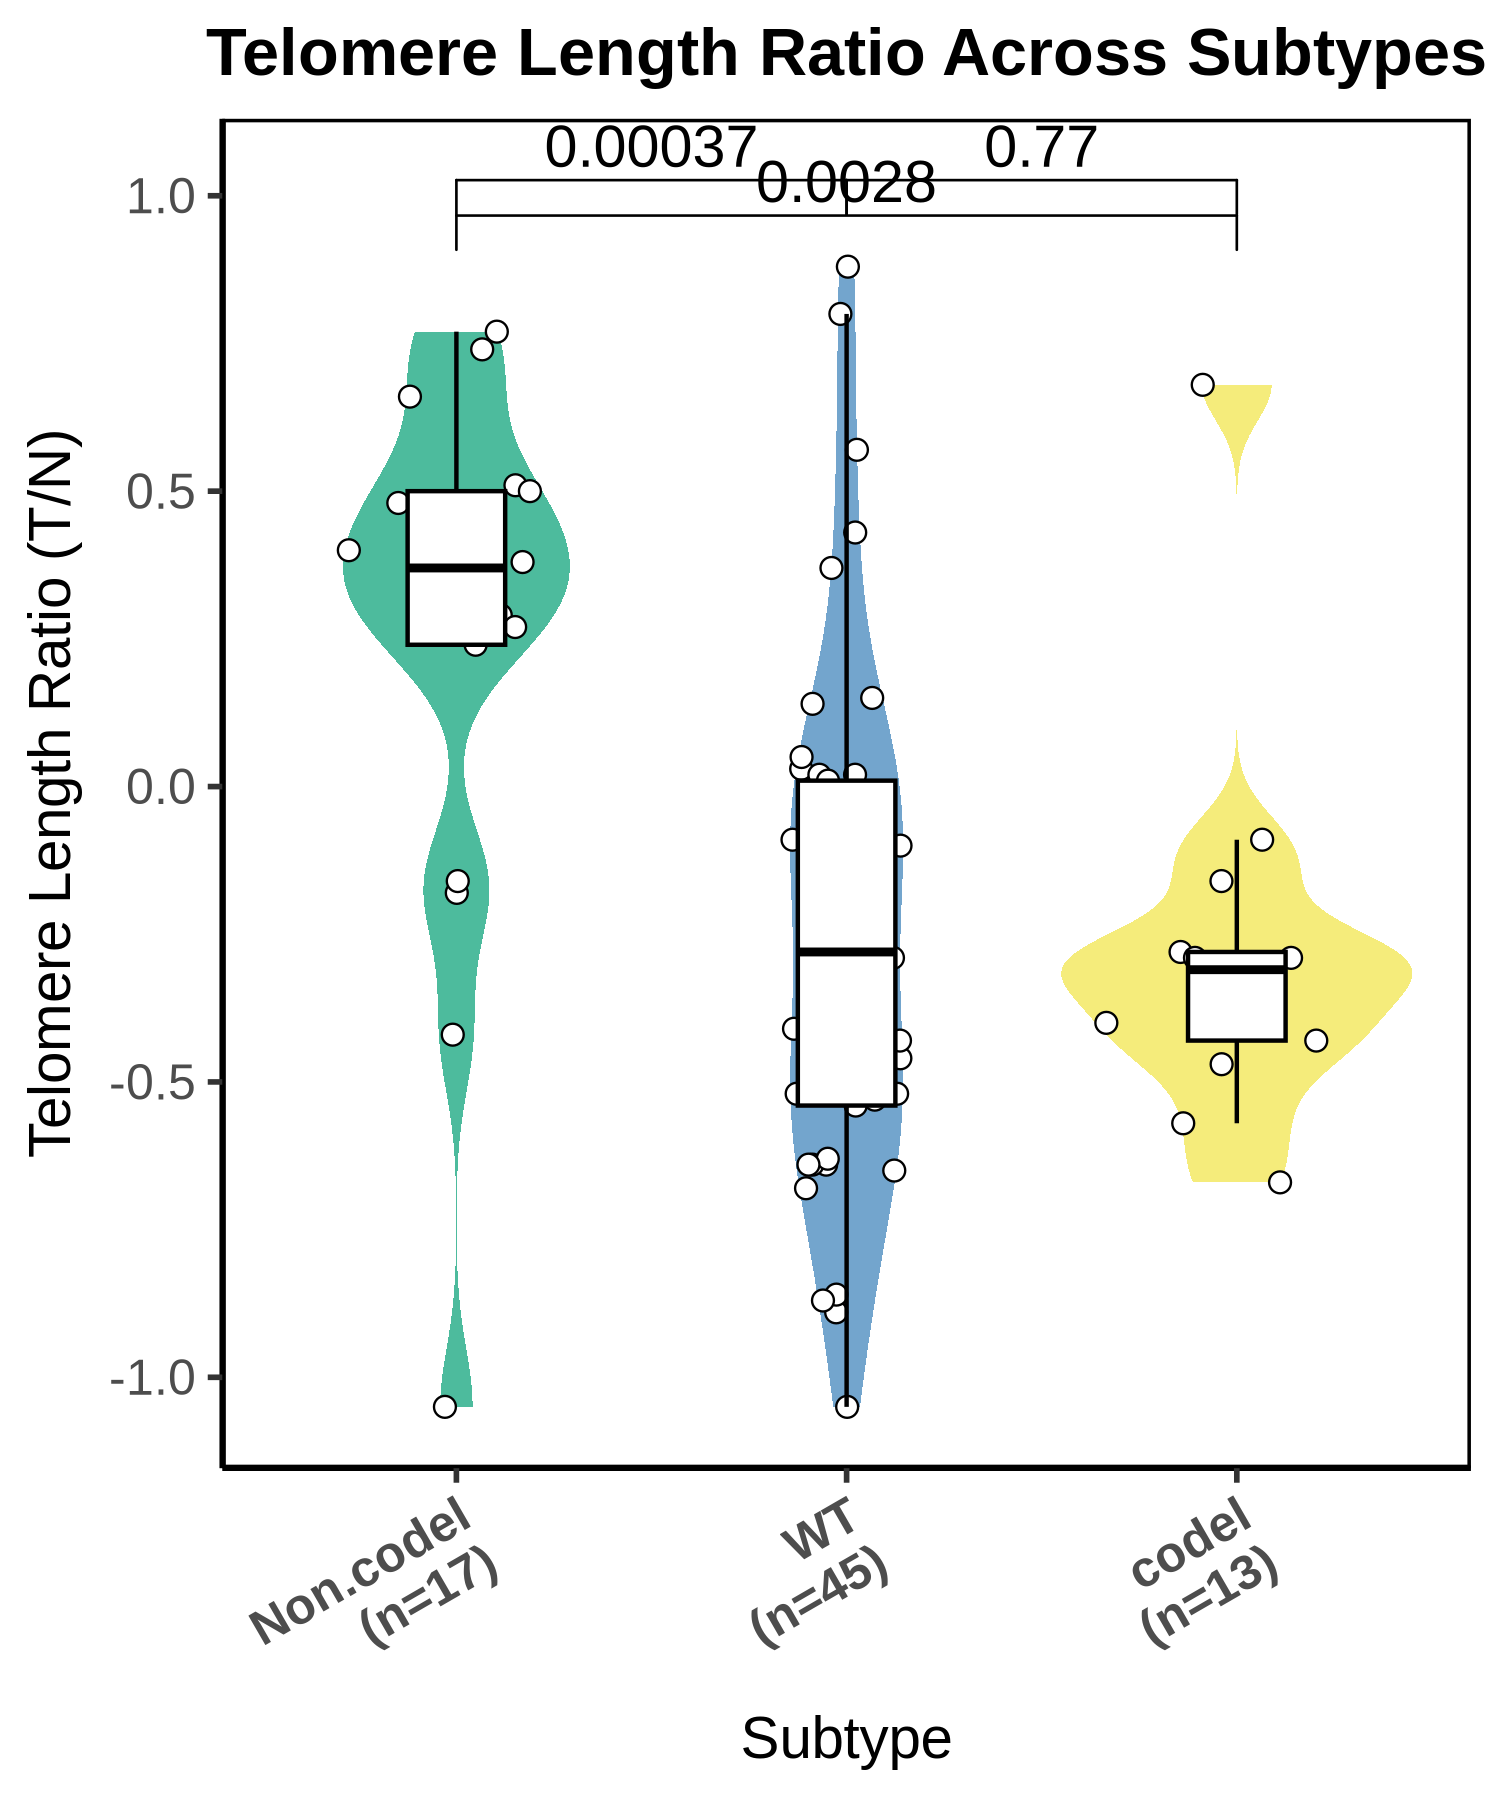

In [112]:
# Violin + boxplot + sina plot
p1 <- ggplot(df, aes(x = subtype, y = TLratio, fill = subtype)) +
  geom_violin(trim = TRUE, alpha = 0.7, color = NA) +
  ggforce::geom_sina(
    shape  = 21,
    size   = 2.2,
    stroke = 0.4,
    color  = "black",
    fill   = "white",
    alpha  = 1
  ) +
  geom_boxplot(
    width = 0.25,
    fill = "white",
    outlier.shape = NA,
    color = "black"
  ) +
  stat_compare_means(
    comparisons = my_comparisons,
    method = "wilcox.test",
    label = "p.value",
    label.y = label_y,
    size = 5,
    tip.length = 0.03
  ) +
  scale_fill_manual(values = subtype_colors) +
  scale_x_discrete(labels = x_labels) +
  labs(
    x = "Subtype",
    y = "Telomere Length Ratio (T/N)",
    title = "Telomere Length Ratio Across Subtypes"
  ) +
  theme_classic(base_size = 14) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 30, hjust = 1, size = 12, face = "bold"),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8)
  )

options(repr.plot.width = 5, repr.plot.height = 6, repr.plot.res = 300)
p1

# Optional save
# ggsave(
#   "/home/mjehangir/telomere-sv-analysis/plots/fig1/TelomereRatio_Subtype.pdf",
#   p1,
#   width = 4,
#   height = 4,
#   dpi = 600
# )

`geom_smooth()` using formula = 'y ~ x'


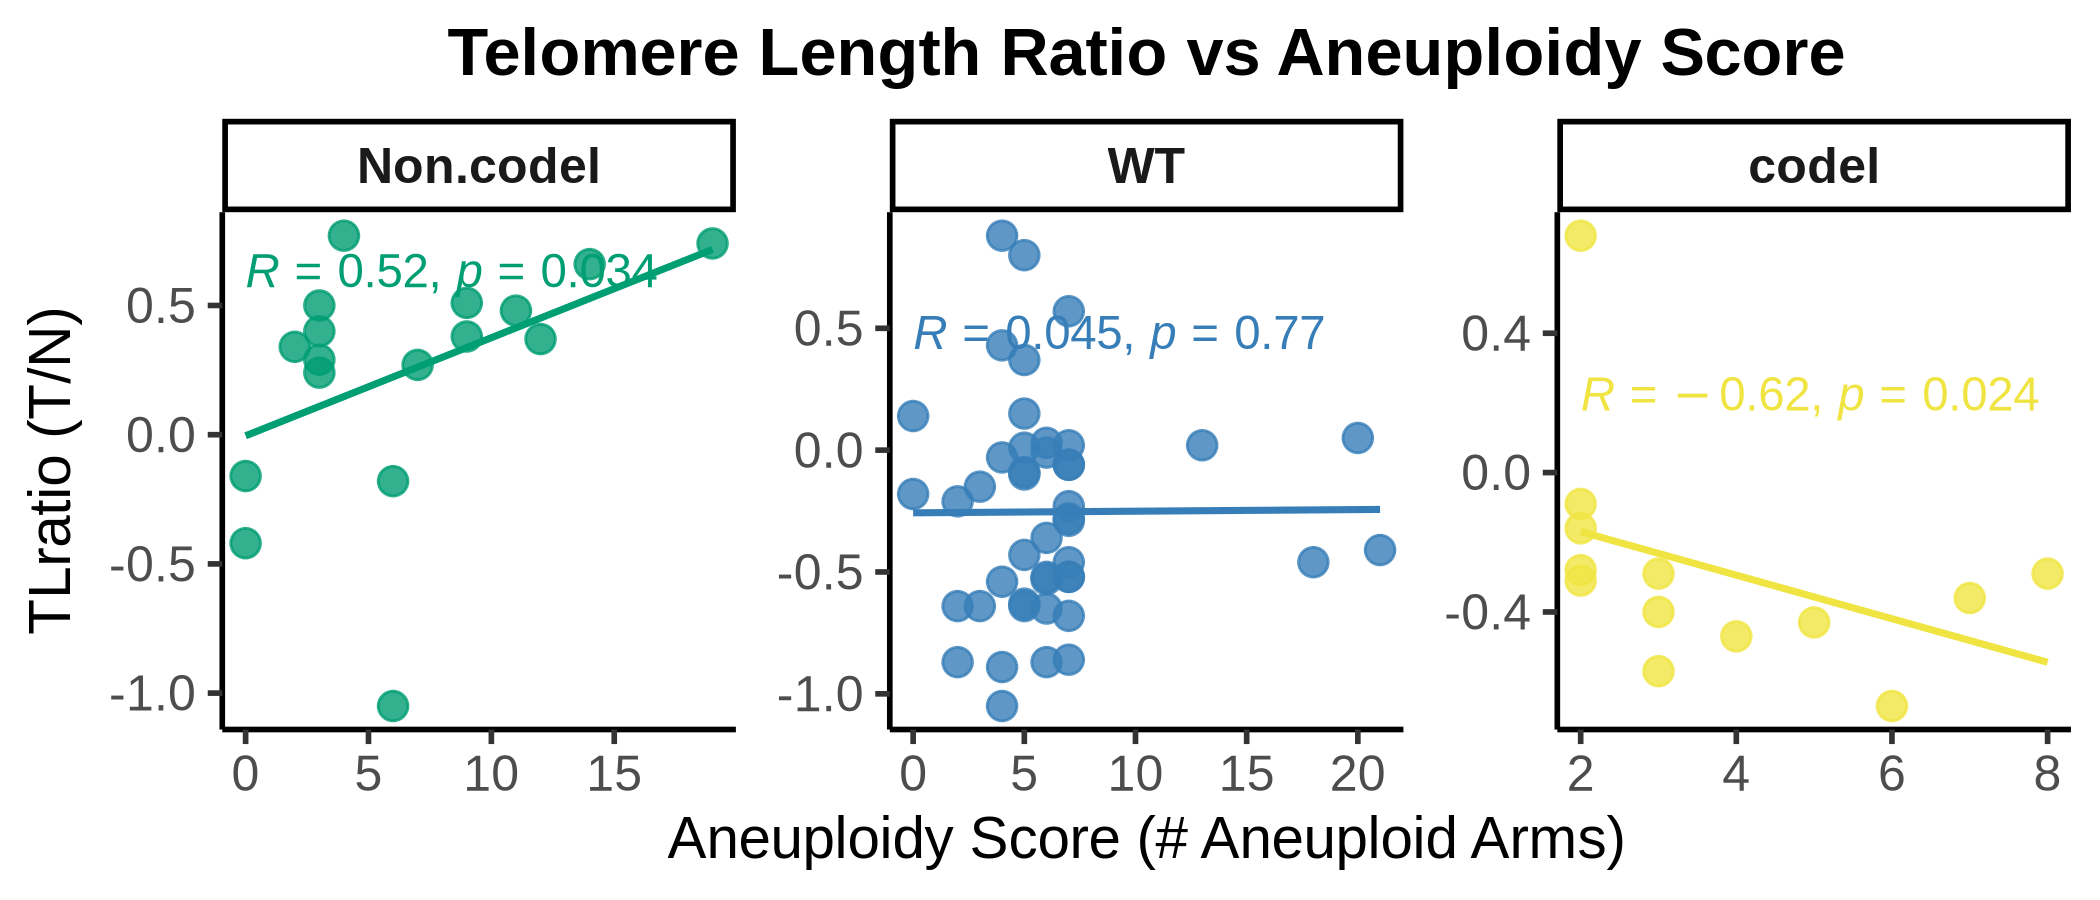

In [113]:
# ============================================================
# 10. Plot 2: TL ratio vs aneuploidy score
# ============================================================

p2 <- ggplot(df, aes(x = aneuploidy_score, y = TLratio, color = subtype)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  facet_wrap(~ subtype, scales = "free") +
  stat_cor(
    method = "spearman",
    label.x.npc = "left",
    label.y.npc = "top",
    size = 4
  ) +
  scale_color_manual(values = subtype_colors) +
  labs(
    title = "Telomere Length Ratio vs Aneuploidy Score",
    x = "Aneuploidy Score (# Aneuploid Arms)",
    y = "TLratio (T/N)"
  ) +
  theme_classic(base_size = 14) +
  theme(
    strip.text = element_text(face = "bold", size = 12),
    legend.position = "none",
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  )
options(repr.plot.width = 7, repr.plot.height = 3, repr.plot.res = 300)

p2

`geom_smooth()` using formula = 'y ~ x'


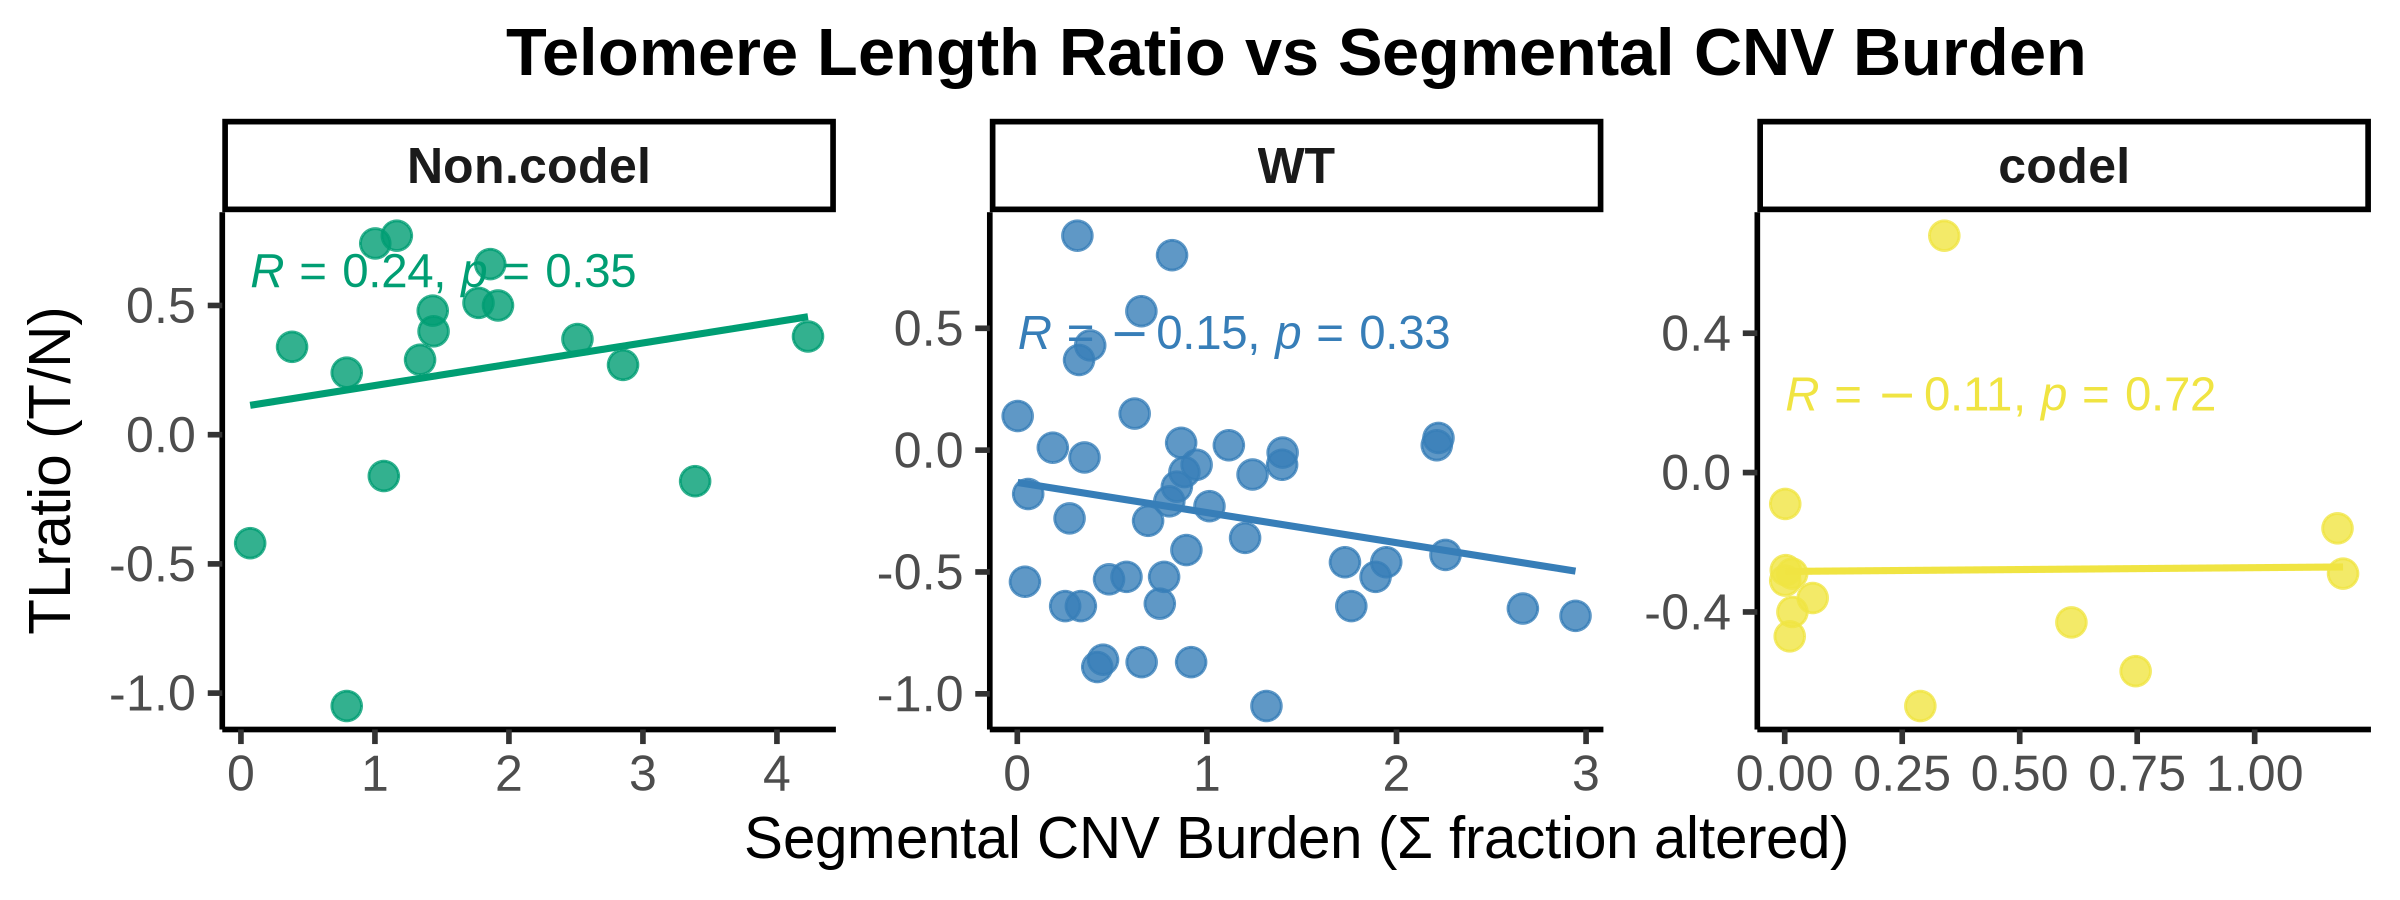

In [114]:
# ============================================================
# 11. Plot 3: TL ratio vs segmental CNV burden
# ============================================================

p3 <- ggplot(df, aes(x = segmental_cnv_burden, y = TLratio, color = subtype)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
  facet_wrap(~ subtype, scales = "free") +
  stat_cor(
    method = "spearman",
    label.x.npc = "left",
    label.y.npc = "top",
    size = 4
  ) +
  scale_color_manual(values = subtype_colors) +
  labs(
    title = "Telomere Length Ratio vs Segmental CNV Burden",
    x = "Segmental CNV Burden (Σ fraction altered)",
    y = "TLratio (T/N)"
  ) +
  theme_classic(base_size = 14) +
  theme(
    strip.text = element_text(face = "bold", size = 12),
    legend.position = "none",
    axis.title = element_text(size = 14),
    axis.text = element_text(size = 12),
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5)
  )

options(repr.plot.width = 8, repr.plot.height = 3, repr.plot.res = 300)

p3